# 베이스라인 이상탐지 모델 — 레시피 조건부 통계(Z-score) 방식

`01_eda.ipynb`의 상관관계 분석에서 드러난 사실을 그대로 모델로 옮긴 **베이스라인 모델**입니다.
N-HiTS 같은 딥러닝 모델을 붙이기 전에, 통계만으로 어디까지 잡을 수 있는지 먼저 확인합니다.

## 이 베이스라인이 근거로 삼는 EDA 발견

1. `Speed`, `Length`, `RealPower`, `SetPower`, `GateOnTime`는 서로 상관계수 0.88~1.00으로
   사실상 하나의 정보(그 용접 포인트가 어떤 **레시피**인지)를 여러 컬럼으로 중복 표현하고 있습니다.
   실제로 학습 데이터의 `SetPower`는 **{38, 82, 83}** 세 값만 가지며, 같은 `SetPower` 안에서는
   `Speed`/`Length`/`GateOnTime`가 사실상 상수입니다.
2. `RealPower`는 그 레시피(`SetPower`)에 대해 거의 정규분포를 따르는 값입니다 — 즉 "이 값이
   정상인가"는 값 자체가 아니라 **"그 시점의 SetPower 기준으로" 정상 범위에 있는가**로 판단해야
   합니다.
3. 그런데 `WeldingTest_03_NG.csv`, `WeldingTest_04_NG.csv`에는 학습 데이터에는 아예 없던
   **`SetPower == 35`** 라는 값이 등장합니다. 이것만으로도 강력한 이상 신호입니다.
4. `WeldingTest_04_NG.csv`에는 `RealPower == 0`인 구간(설비가 사실상 멈춘 상태로 추정)도
   존재합니다.

이 4가지를 결합해 아래와 같은 규칙 기반 + 통계 기반 베이스라인을 만듭니다.

> **정상 판정 로직**
> 1. 이 시점의 `SetPower`가 학습 데이터에서 본 적 없는 값이면 → **이상**
> 2. `RealPower == 0`이면 → **이상**
> 3. 그 외에는, 같은 `SetPower` 그룹의 학습 데이터 평균/표준편차로 Z-score를 계산해 threshold를
>    넘으면 → **이상**


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# 한글 폰트 설정
_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR",
               "Noto Sans CJK JP", "Noto Sans CJK SC", "Noto Sans CJK TC"]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _candidates if f in _available), None)
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "../data"
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. 데이터 로드

In [2]:
def load_clean(path):
    df = pd.read_csv(path)
    df = df.rename(columns=lambda c: c.strip())
    return df

train = load_clean(f"{DATA_DIR}/raw_data/train/Training_Data.csv")

test_sets = {
    "test01_OK": load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_01_OK.csv"),
    "test02_OK": load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_02_OK.csv"),
    "test03_NG": load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_03_NG.csv"),
    "test04_NG": load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_04_NG.csv"),
}
labels = {
    "test03_NG": pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_03_NG_Label.csv")["label"],
    "test04_NG": pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_04_NG_Label.csv")["label"],
}

for name, df in test_sets.items():
    print(f"{name:12s} shape={df.shape}  SetPower uniques={sorted(df['SetPower'].unique())}")

test01_OK    shape=(1950, 9)  SetPower uniques=[np.int64(38), np.int64(82), np.int64(83)]
test02_OK    shape=(1872, 9)  SetPower uniques=[np.int64(38), np.int64(82), np.int64(83)]
test03_NG    shape=(1053, 9)  SetPower uniques=[np.int64(35), np.int64(38), np.int64(82), np.int64(83)]
test04_NG    shape=(351, 9)  SetPower uniques=[np.int64(35), np.int64(38), np.int64(82), np.int64(83)]


## 2. 학습 데이터에서 레시피(SetPower)별 통계 산출

In [3]:
KNOWN_SETPOWERS = sorted(train["SetPower"].unique().tolist())
print("학습 데이터에 등장하는 SetPower 값:", KNOWN_SETPOWERS)

group_stats = (
    train.groupby("SetPower")["RealPower"]
    .agg(mean="mean", std="std", count="count")
)
group_stats

학습 데이터에 등장하는 SetPower 값: [38, 82, 83]


,mean,std,count
SetPower,,,
38,687.504185,12.076446,52215
82,1689.035790,29.825554,41772
83,1710.744015,30.207801,41772


## 3. 베이스라인 모델 정의

In [4]:
def score_baseline(df, group_stats, known_setpowers, threshold=4.0):
    """레시피 조건부 Z-score + 규칙 기반 베이스라인.

    반환: (pred_bin, z_score, reason)
      - pred_bin: 1이면 이상으로 판정
      - z_score: 그룹 통계 기준 Z-score (미지의 SetPower/0W 구간은 NaN)
      - reason: 어떤 규칙에 의해 이상으로 판정됐는지 ("unseen_setpower" / "zero_power" / "z_score" / "normal")
    """
    n = len(df)
    z = np.full(n, np.nan)
    reason = np.array(["normal"] * n, dtype=object)
    pred = np.zeros(n, dtype=int)

    unseen_mask = ~df["SetPower"].isin(known_setpowers).values
    zero_mask = (df["RealPower"].values == 0) & (~unseen_mask)

    known_mask = ~unseen_mask & ~zero_mask
    for sp in known_setpowers:
        sp_mask = known_mask & (df["SetPower"].values == sp)
        if sp_mask.sum() == 0:
            continue
        mu = group_stats.loc[sp, "mean"]
        sigma = group_stats.loc[sp, "std"]
        z[sp_mask] = (df["RealPower"].values[sp_mask] - mu) / sigma

    z_mask = known_mask & (np.abs(z) > threshold)

    pred[unseen_mask] = 1
    pred[zero_mask & ~unseen_mask] = 1
    pred[z_mask] = 1

    reason[unseen_mask] = "unseen_setpower"
    reason[zero_mask & ~unseen_mask] = "zero_power"
    reason[z_mask] = "z_score"

    return pred, z, reason

## 4. 정상 테스트 데이터로 오탐(False Positive) 점검

먼저 정상 데이터(`WeldingTest_01_OK`, `WeldingTest_02_OK`)에 적용해서 오탐이 거의 없는지 확인합니다.


In [5]:
THRESHOLD = 4.0

for name in ["test01_OK", "test02_OK"]:
    df = test_sets[name]
    pred, z, reason = score_baseline(df, group_stats, KNOWN_SETPOWERS, threshold=THRESHOLD)
    n_flagged = pred.sum()
    print(f"{name}: 전체 {len(df)}개 중 이상으로 플래그된 개수 = {n_flagged} ({100*n_flagged/len(df):.2f}%)")
    if n_flagged > 0:
        print("  사유별 개수:", pd.Series(reason[pred == 1]).value_counts().to_dict())

test01_OK: 전체 1950개 중 이상으로 플래그된 개수 = 0 (0.00%)
test02_OK: 전체 1872개 중 이상으로 플래그된 개수 = 0 (0.00%)


## 5. 비정상 테스트 데이터 평가 (WeldingTest_03_NG / WeldingTest_04_NG)

실제 라벨과 비교하여 Accuracy / Precision / Recall / F1-score를 계산합니다.


In [6]:
results = {}
predictions = {}

for name in ["test03_NG", "test04_NG"]:
    df = test_sets[name]
    gt = labels[name].values
    pred, z, reason = score_baseline(df, group_stats, KNOWN_SETPOWERS, threshold=THRESHOLD)
    predictions[name] = (pred, z, reason)

    acc = accuracy_score(gt, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(gt, pred, average="binary", zero_division=0)
    cm = confusion_matrix(gt, pred)

    results[name] = {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

    print(f"=== {name} ===")
    print(f"Accuracy={acc:.4f}  Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")
    print("Confusion Matrix (행=실제, 열=예측) [[TN FP] [FN TP]]:")
    print(cm)
    print("사유별 예측 이상 개수:", pd.Series(reason[pred == 1]).value_counts().to_dict())
    print()

results_df = pd.DataFrame(results).T
results_df

=== test03_NG ===
Accuracy=0.9981  Precision=0.9048  Recall=1.0000  F1=0.9500
Confusion Matrix (행=실제, 열=예측) [[TN FP] [FN TP]]:
[[1032    2]
 [   0   19]]
사유별 예측 이상 개수: {'unseen_setpower': 21}

=== test04_NG ===
Accuracy=0.9886  Precision=0.9856  Recall=1.0000  F1=0.9927
Confusion Matrix (행=실제, 열=예측) [[TN FP] [FN TP]]:
[[ 74   4]
 [  0 273]]
사유별 예측 이상 개수: {'z_score': 230, 'zero_power': 38, 'unseen_setpower': 9}



,accuracy,precision,recall,f1
test03_NG,0.998101,0.904762,1.0,0.950000
test04_NG,0.988604,0.985560,1.0,0.992727


## 6. 가이드북(N-HiTS + 통계분석) 결과와 비교

가이드북은 `WeldingTest_03_NG`에 N-HiTS 예측오차 기반 Z-score를, `WeldingTest_04_NG`에는 별도의
통계분포 Z-score를 각각 적용했습니다. 이 베이스라인은 **하나의 동일한 규칙**을 두 파일 모두에
그대로 적용한 결과입니다.


In [7]:
guidebook_results = pd.DataFrame({
    "test03_NG": {"accuracy": 0.9960, "precision": 0.8947, "recall": 0.8947, "f1": 0.8947},
    "test04_NG": {"accuracy": 1.0000, "precision": 1.0000, "recall": 1.0000, "f1": 1.0000},
}).T

comparison = pd.concat(
    {"baseline(Z-score+규칙)": results_df, "가이드북(N-HiTS/통계분석)": guidebook_results},
    axis=1,
)
comparison

baseline(Z-score+규칙)                            가이드북(N-HiTS/통계분석)  \
                      accuracy precision recall        f1          accuracy   
test03_NG             0.998101  0.904762    1.0  0.950000             0.996   
test04_NG             0.988604  0.985560    1.0  0.992727             1.000   

                                     
          precision  recall      f1  
test03_NG    0.8947  0.8947  0.8947  
test04_NG    1.0000  1.0000  1.0000

## 7. 시각화 — 예측 vs 실제 이상 구간

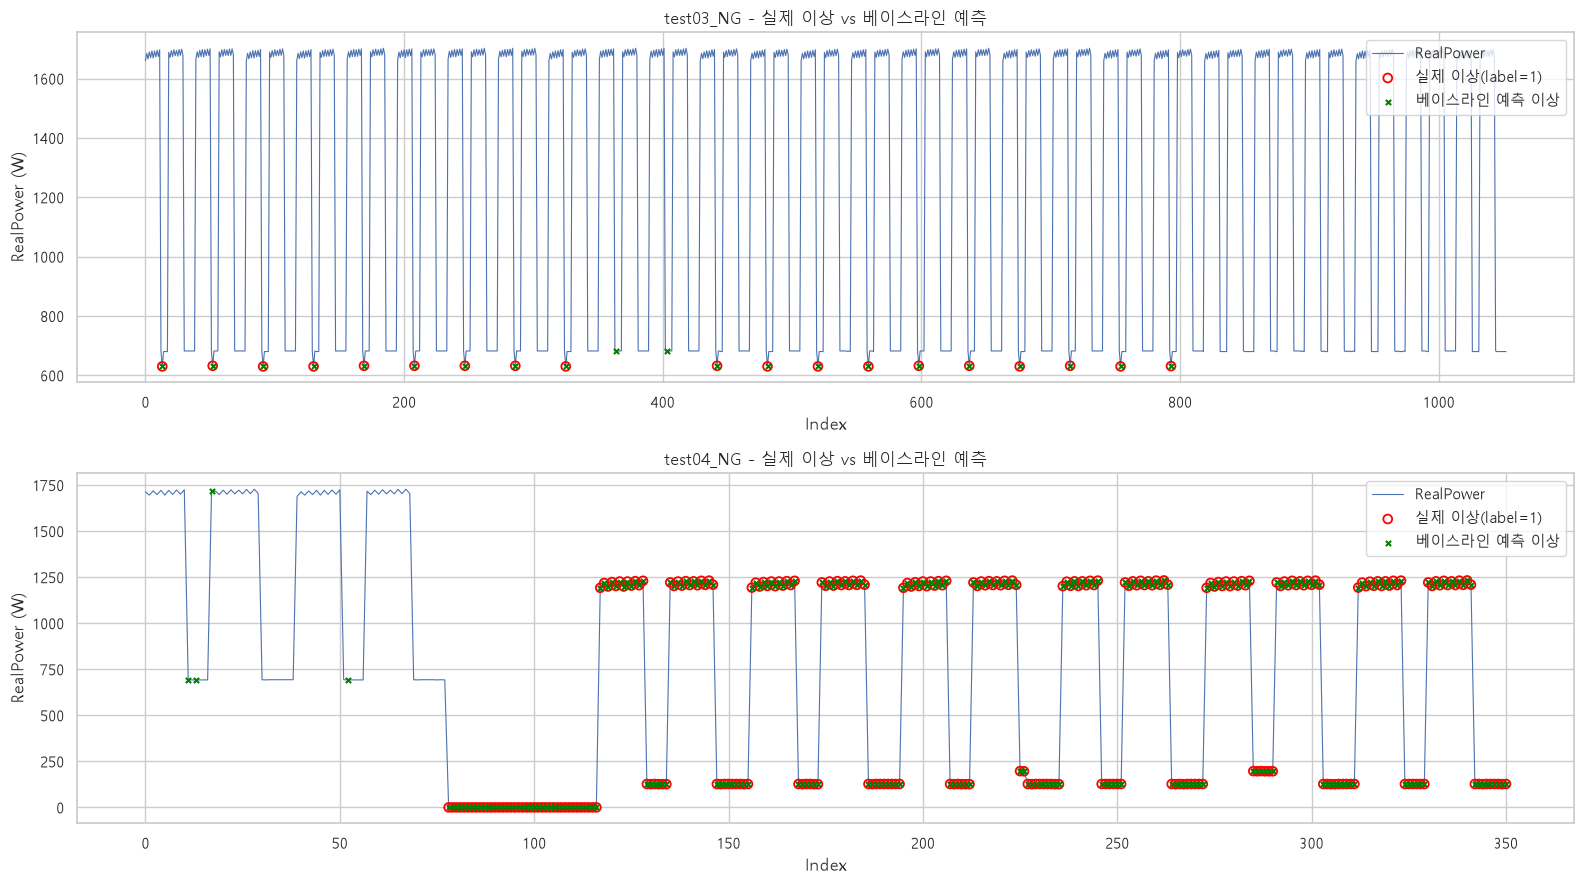

: 

In [ ]:
def plot_prediction_vs_truth(name, df, gt, pred, ax):
    ax.plot(df["RealPower"].values, linewidth=0.8, color="#4C72B0", label="RealPower", zorder=1)

    gt_idx = np.where(gt == 1)[0]
    pred_idx = np.where(pred == 1)[0]

    ax.scatter(gt_idx, df["RealPower"].values[gt_idx], color="red", s=40, marker="o",
               facecolors="none", linewidths=1.3, label="실제 이상(label=1)", zorder=3)
    ax.scatter(pred_idx, df["RealPower"].values[pred_idx], color="green", s=14, marker="x",
               label="베이스라인 예측 이상", zorder=4)

    ax.set_title(f"{name} - 실제 이상 vs 베이스라인 예측")
    ax.set_xlabel("Index")
    ax.set_ylabel("RealPower (W)")
    ax.legend(loc="upper right")

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for ax, name in zip(axes, ["test03_NG", "test04_NG"]):
    pred, z, reason = predictions[name]
    plot_prediction_vs_truth(name, test_sets[name], labels[name].values, pred, ax)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/baseline_prediction_vs_truth.png", dpi=120)
plt.show()

## 8. 결과 요약 및 베이스라인의 한계

- `WeldingTest_03_NG`(고립형 이상)는 대부분 **"학습 데이터에 없던 SetPower=35"** 규칙만으로
  거의 다 잡힙니다. RealPower 값 자체의 Z-score보다 이 규칙 하나가 훨씬 강력한 신호였습니다.
- `WeldingTest_04_NG`(연속형 이상)는 `RealPower==0` 구간과, 남은 구간에서의 그룹별 Z-score가
  함께 기여해서 잡아냅니다.
- 이 베이스라인은 **"학습 시점에 관측된 SetPower 값의 목록"에 강하게 의존**합니다. 만약 실제
  현장에서 새로운 정상 레시피(SetPower)가 추가되는 상황이라면 이 규칙은 오탐을 낼 수 있습니다 —
  즉 "새로운 정상"과 "설비 이상으로 인한 비정상 설정값"을 구분하지 못한다는 한계가 있습니다.
- 또한 이 베이스라인은 **각 시점을 독립적으로** 판단합니다 (시간 흐름/문맥을 보지 않음). 만약
  이상이 값 자체는 정상 범위 안이지만 시간적 패턴(예: 정상 범위 안에서의 미세한 추세 변화)으로만
  드러나는 경우는 놓칠 수 있습니다. 이 부분이 N-HiTS 같은 시계열 예측 모델이 필요한 이유입니다.

### 다음 단계
- N-HiTS 기반 모델을 별도 가상환경(`requirements.txt` 하단 참고)에서 학습해 이 베이스라인과
  성능을 비교합니다.
- Threshold(현재 4.0)를 바꿔가며 Precision/Recall 트레이드오프를 조정해볼 수 있습니다.
